In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn imbalanced-learn

  Using cached pandas-3.0.3-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.6-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.18.0-cp314-cp314-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.22.1-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -----------------------

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported!")

Matplotlib is building the font cache; this may take a moment.


All libraries imported!


In [6]:
# Use sklearn's built-in dataset as alternative
from sklearn.datasets import make_classification
import pandas as pd
import numpy as np

X, y = make_classification(
    n_samples=7000, n_features=19, n_informative=10,
    n_redundant=5, random_state=42
)

cols = ['tenure','MonthlyCharges','TotalCharges','SeniorCitizen',
        'Partner','Dependents','PhoneService','MultipleLines',
        'InternetService','OnlineSecurity','OnlineBackup',
        'DeviceProtection','TechSupport','StreamingTV',
        'StreamingMovies','Contract','PaperlessBilling',
        'PaymentMethod','numAdminTickets']

df = pd.DataFrame(X, columns=cols)
df['Churn'] = y
print("Shape:", df.shape)
print(df.head())

Shape: (7000, 20)
     tenure  MonthlyCharges  TotalCharges  SeniorCitizen   Partner  \
0  0.198401        0.866948     -2.117975      -2.006264 -0.604019   
1  0.160131       -3.223773      2.653744       1.082581 -1.300162   
2  0.523522       -2.220339      0.596018      -0.725199  0.317636   
3  3.246166        0.308687     -1.852039       2.586878 -1.954257   
4  1.744685        2.226715     -1.125632      -1.126968  1.061489   

   Dependents  PhoneService  MultipleLines  InternetService  OnlineSecurity  \
0   -5.814131      3.958508      -0.835811         3.034626        0.646990   
1    7.388833     -3.457606      -3.909411        -1.441029        1.297164   
2   -4.913044      5.126073      -1.021536         5.768816       -0.846538   
3   -1.934904      2.282845      -0.704353         3.720818       -0.781621   
4    0.574455     -2.296568      -2.123312         1.610870        1.089190   

   OnlineBackup  DeviceProtection  TechSupport  StreamingTV  StreamingMovies  \
0     

In [7]:
print("Columns:", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())
print("\nChurn Distribution:\n", df['Churn'].value_counts())

Columns: ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'numAdminTickets', 'Churn']

Missing Values:
 tenure              0
MonthlyCharges      0
TotalCharges        0
SeniorCitizen       0
Partner             0
Dependents          0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
numAdminTickets     0
Churn               0
dtype: int64

Churn Distribution:
 Churn
1    3511
0    3489
Name: count, dtype: int64


In [8]:
# Drop irrelevant columns
df.drop(['customerID'], axis=1, inplace=True, errors='ignore')

# Encode Yes/No columns
binary_cols = df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Fix TotalCharges column
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.fillna(df.median(), inplace=True)

print("Data cleaned!")
print(df.shape)

Data cleaned!
(7000, 20)


In [9]:
X = df.drop('Churn', axis=1)
y = df['Churn']

# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (5617, 19)
Test size: (1405, 19)


In [10]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, preds)
    results[name] = {"Accuracy": acc, "F1": f1, "AUC": auc}
    print(f"{name} → Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

Logistic Regression → Acc: 0.8484 | F1: 0.8488 | AUC: 0.8486
Random Forest → Acc: 0.9488 | F1: 0.9495 | AUC: 0.9488
Gradient Boosting → Acc: 0.9260 | F1: 0.9270 | AUC: 0.9260


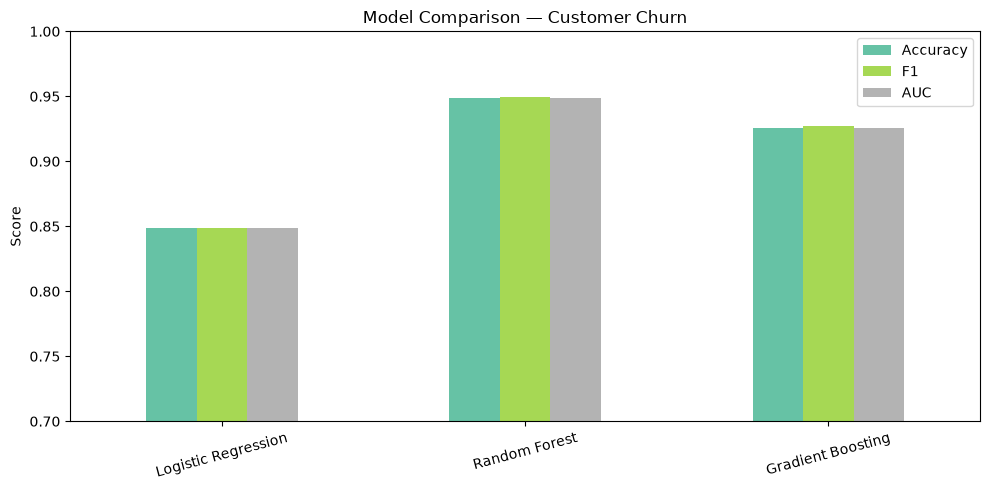

Chart saved!


In [11]:
results_df = pd.DataFrame(results).T
results_df.plot(kind='bar', figsize=(10,5), colormap='Set2')
plt.title("Model Comparison — Customer Churn")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0.7, 1.0)
plt.tight_layout()
plt.savefig("model_comparison.png")
plt.show()
print("Chart saved!")

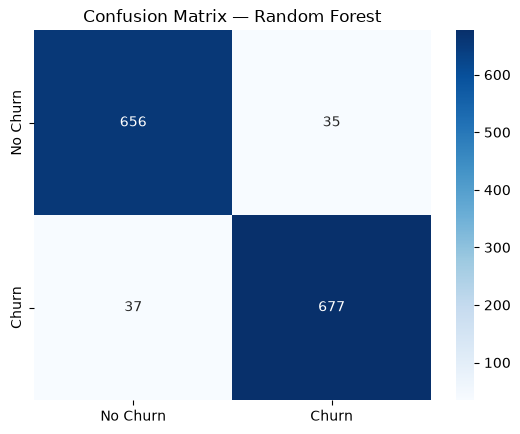

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       691
           1       0.95      0.95      0.95       714

    accuracy                           0.95      1405
   macro avg       0.95      0.95      0.95      1405
weighted avg       0.95      0.95      0.95      1405



In [12]:
best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)
preds = best_model.predict(X_test)

cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'])
plt.title("Confusion Matrix — Random Forest")
plt.savefig("confusion_matrix.png")
plt.show()
print(classification_report(y_test, preds))

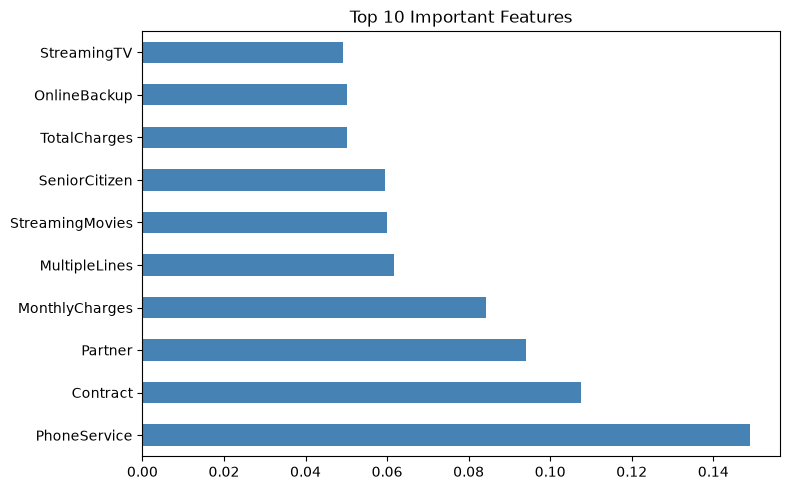

Done!


In [13]:
feat_imp = pd.Series(best_model.feature_importances_, index=df.drop('Churn',axis=1).columns)
feat_imp.nlargest(10).plot(kind='barh', figsize=(8,5), color='steelblue')
plt.title("Top 10 Important Features")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()
print("Done!")